In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
sc.settings.set_figure_params(dpi=100)
import warnings
warnings.filterwarnings('ignore')
print()

### Helper Functions

In [2]:
# define a function to normalize a dataset
def normalize_gex(gex):
    return (gex.T / np.sqrt((gex ** 2).sum(1))).T
# define a function to clip the data to a given range
def clip(gex, low, high):
    gex[gex < low] = low
    gex[gex > high] = high
    return gex
# define a function to compute RMSE
def rmse(old, new):
    return np.sqrt(np.mean((new - old) ** 2))
# define a function to add noise
def add_noise(gex, std):
    gex += np.random.normal(0, std, size=(n_cells, n_genes))
    return gex

### Generate Complex Directed Graphs

In [3]:
import torch
import torch_geometric
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv
from sklearn.neighbors import kneighbors_graph
# define the number of neighbors (six for visium)
n_neighbors = 6
# define the celcomen class
class celcomen(torch.nn.Module):
    # define initialization function
    def __init__(self, input_dim, output_dim, n_neighbors, seed=0):
        super(celcomen, self).__init__()
        # define the seed
        torch.manual_seed(seed)
        # set up the graph convolution
        self.conv1 = GCNConv(input_dim, output_dim, add_self_loops=False)
        # set up the linear layer for intracellular gene regulation
        self.lin = torch.nn.Linear(input_dim, output_dim)
        # define the neighbors
        self.n_neighbors = n_neighbors
        # define a tracking variable for the gene expression x matrix
        self.gex = None

    # define a function to artificially set the g2g matrix
    def set_g2g(self, g2g):
        """
        Artifically sets the core g2g matrix to be a specified interaction matrix
        """
        # set the weight as the input
        self.conv1.lin.weight = torch.nn.Parameter(g2g, requires_grad=True)
        # and then set the bias as all zeros
        self.conv1.bias = torch.nn.Parameter(torch.from_numpy(np.zeros(len(g2g)).astype('float32')), requires_grad=False)

    # define a function to artificially set the g2g matrix
    def set_g2g_intra(self, g2g_intra):
        """
        Artifically sets the core g2g intracellular matrix to be a specified matrix
        """
        # set the weight as the input
        self.lin.weight = torch.nn.Parameter(g2g_intra, requires_grad=True)
        # and then set the bias as all zeros
        self.lin.bias = torch.nn.Parameter(torch.from_numpy(np.zeros(len(g2g_intra)).astype('float32')), requires_grad=False)

    # define a function to artificially set the sphex matrix
    def set_gex(self, gex):
        """
        Artifically sets the current sphex matrix
        """
        self.gex = torch.nn.Parameter(gex, requires_grad=False)
        
    # define the forward pass
    def forward(self, edge_index, batch):
        """
        Forward pass for prediction or training,
        convolutes the input by the expected interactions and returns log(Z_mft)
        """
        # compute the message
        msg = self.conv1(self.gex, edge_index)
        # compute intracellular message
        msg_intra = self.lin(self.gex)
        # compute the log z mft
        log_z_mft = self.log_Z_mft(edge_index, batch)
        return msg, msg_intra, log_z_mft

    # define approximation function
    def log_Z_mft(self, edge_index, batch):
        """
        Mean Field Theory approximation to the partition function. Assumptions used are:
        - expression of values of genes are close to their mean values over the visium slide
        - \sum_b g_{a,b} m^b >0 \forall a, where m is the mean gene expression and g is the gene-gene
          interaction matrix.
        """
        # retrieve number of spots
        num_spots = self.gex.shape[0]
        # calculate mean gene expression        
        mean_genes = torch.mean(self.gex, axis=0).reshape(-1,1)  # the mean should be per connected graph
        # calculate the norm of the sum of mean genes
        g = torch.norm(torch.mm( self.n_neighbors*self.conv1.lin.weight + 2*self.lin.weight, mean_genes))   # maybe needs to change to g = torch.norm(torch.mm(mean_genes, self.conv1.lin.weight))
        # calculate the contribution for mean values        
        z_mean = - num_spots  * torch.mm(torch.mm(torch.t(mean_genes), self.lin.weight + 0.5 * self.n_neighbors * self.conv1.lin.weight),  mean_genes)
        # calculate the contribution gene interactions
        z_interaction = self.z_interaction(num_spots=num_spots, g=g)
        # add the two contributions        
        log_z_mft = z_mean + z_interaction
        return log_z_mft

    def z_interaction(self, num_spots, g):
        """
        Avoid exploding exponentials by returning an approximate interaction term for the partition function.
        """
        if g>20:
            z_interaction = num_spots * ( g - torch.log( g) )
        else:
            z_interaction = num_spots * torch.log((torch.exp( g) - torch.exp(- g))/( g))
        return z_interaction

# define a function to normalize the g2g
def normalize_g2g(g2g):
    """
    Addresses any small fluctuations in symmetrical weights
    """
    # symmetrize the values
    g2g = (g2g + g2g.T) / 2
    # force them to be between 0-1
    g2g[g2g < 0] = 0
    g2g[g2g > 1] = 1
    # force the central line to be 1
    for idx in range(len(g2g)):
        g2g[idx, idx] = 1
    return g2g

In [4]:
# instantiate the model, input and output will be the same
def train_celcomen(data_loader, n_genes, n_neighbors, seed):
    # instantiate model
    model_rev = celcomen(input_dim=n_genes, output_dim=n_genes, n_neighbors=n_neighbors, seed=seed)
    # now perform the simulation
    np.random.seed(seed)
    # artifically set the g2g matrix
    input_g2g = np.random.uniform(size=(n_genes, n_genes)).astype('float32')
    input_g2g = normalize_g2g((input_g2g + input_g2g.T) / 2)
    model_rev.set_g2g(torch.from_numpy(input_g2g))
    model_rev.set_g2g_intra(torch.from_numpy(input_g2g))

    # setup the initial optimizer
    optimizer = torch.optim.SGD(model_rev.parameters(), lr=learning_rate, momentum=0)
    # keep track of the losses
    losses = []
    model_rev.train()
    # retrieve the two matrices
    epoch = -1
    # work through epochs
    for epoch in range(epochs):
        # loop thorugh each data object
        losses_ = []
        for idx, data in enumerate(data_loader):
            # set the appropriate gex
            model_rev.set_gex(data.x)
            # derive the message as well as the mean field approximation
            msg, msg_intra, log_z_mft = model_rev(data.edge_index, 1)
            # compute the loss and track it
            loss = -(-log_z_mft + zmft_scalar * torch.trace(torch.mm(msg, torch.t(model_rev.gex))) + zmft_scalar * torch.trace(torch.mm(msg_intra, torch.t(model_rev.gex))) )
            losses_.append(loss.detach().numpy()[0][0])
            # derive the gradients, update, and clear
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            # repeatedly force a normalization
            model_rev.conv1.lin.weight = torch.nn.Parameter(normalize_g2g(model_rev.conv1.lin.weight), requires_grad=True)
            model_rev.lin.weight = torch.nn.Parameter(normalize_g2g(model_rev.lin.weight), requires_grad=True)
            optimizer = torch.optim.SGD(model_rev.parameters(), lr=learning_rate, momentum=0)
        losses.append(np.mean(losses_))
    return model_rev, losses

In [5]:
def create_loader(adata):
    # create a tracking variable of the datas for the dataloader
    data_list = []
    # loop through each sample
    for batch in adata.obs['batch'].unique():
        # define the mask
        mask = adata.obs['batch'] == batch
        # retrieve positions from the data
        pos = torch.from_numpy(adata[mask].obsm['spatial'].astype('float32'))
        # convert the gene expression data to numpy
        x = torch.from_numpy(adata[mask, :].X.astype('float32'))
        # sphere normalize the data (just in case)
        norm_factor = torch.pow(x, 2).sum(1).reshape(-1,1)
        assert (norm_factor > 0).all()
        x = torch.div(x, norm_factor)
        y = torch.Tensor([0])  # here we will store GT value
        # find the edges via kneighbors, not including self because we are considering intercellular
        edge_index = kneighbors_graph(pos, n_neighbors, include_self=False).todense()
        edge_index = torch.from_numpy(np.array(np.where(edge_index)))
        # create the final torch geometric graph dataframe
        data = torch_geometric.data.Data(x=x, pos=pos, y=y, edge_index=edge_index)
        data.validate(raise_on_error=True)  # performs basic checks on the graph
        # store the data in the data list tracker
        data_list.append(data)
    # convert into a data loader
    data_loader = DataLoader(data_list, batch_size=1, shuffle=True)
    return data_loader

In [6]:
from scipy.spatial.distance import pdist, cdist, squareform
from anndata import AnnData
# define a function to create potential graphs
def gen_data(n_genes, n_cells, iters, rounds, learning_rate, seed):
    # generate nodes based on the data
    nodes = np.arange(n_genes)
    # randomly determine intracellular edges
    np.random.seed(seed)
    edges_intra = []
    while len(edges_intra) < 1:
        for start in nodes[:]:
            for end in nodes[start:]:
                strength = generation_function(start, end, 'intra')
                edges_intra.append([start, end, strength])
    if extra_intra_edges_same:
        edges_extra = edges_intra
    else:
        edges_extra = []
        while len(edges_extra) < 1:
            for start in nodes[:]:
                for end in nodes[start:]:
                    strength = generation_function(start, end, 'extra')
                    edges_extra.append([start, end, strength])
    # loop through random seeds to generate data
    adatas = []
    # plot the RMSEs
    np.random.seed(seed)
    # fig, ax = plt.subplots(figsize=[4, 2]); ax.grid(False)
    for batch in range(rounds):
        # instantiate
        gex = [np.nan]
        # normalize the dataset according to the ruleset
        while np.isnan(gex).any():
            # generate a random dataset
            gex = np.random.uniform(0, 1, size=(n_cells, n_genes))
            gex = normalize_gex(gex)
            # create 10, 10 grids for spatial
            ys = np.repeat(np.arange(10).reshape(-1, 1), 10, axis=1)
            ys = ys.flatten().astype(float).tolist()
            xs = np.repeat(np.arange(10).reshape(-1, 1), 10, axis=1).T
            xs = xs.flatten().astype(float).tolist()
            spatial = np.array([xs, ys]).T
            spatial[:, 0][spatial[:, 1] % 2 == 0] -= 0.5
            # compute distances for the mask
            dist = squareform(pdist(spatial))
            mask = (dist > 0) & (dist <= 1)
            rmses = []
            for _ in range(iters):
                # retrieve the data
                gex_new = gex.copy()
                gex_new_nn = mask @ gex_new
                # adjust the data according to edges intracellular
                order = np.random.choice(range(len(edges_intra)), size=len(edges_intra), replace=False)
                edges_ordered = [edges_intra[idx] for idx in order]
                for node1, node2, weight in edges_ordered:
                    gex_new[:, node2] += gex_new[:, node1] * weight * learning_rate
                # adjust the data according to edges extracellular
                order = np.random.choice(range(len(edges_extra)), size=len(edges_extra), replace=False)
                edges_ordered = [edges_extra[idx] for idx in order]
                for node1, node2, weight in edges_ordered:
                    gex_new[:, node2] += gex_new_nn[:, node1] * weight * learning_rate
                # normalize the data
                gex_new = clip(gex_new, 0, 1)
                gex_new = add_noise(gex_new, 0.1)
                gex_new = clip(gex_new, 0, 1)
                gex_new = normalize_gex(gex_new)
                rmses.append(rmse(gex, gex_new))
                gex = gex_new
        # convert into anndata object
        adata = AnnData(gex)
        adata.obsm['spatial'] = spatial
        adatas.append(adata)
        # plot the RMSEs
        # ax.plot(range(1, len(rmses)+1), rmses, color='tab:blue', linestyle='--', alpha=0.5)
    # ax.set(xlabel='Epochs', ylabel='RMSE from\nPrevious')
    
    # aggregate the data together
    adata = adatas[0].concatenate(adatas[1:])
    return adata, edges_intra, edges_extra

In [7]:
# define function to evaluate the results
def evaluate(df_intra, df_extra, edges_intra, edges_extra, adjustment_function, model):
    # load into the prediction frame
    df_in = pd.DataFrame(columns=['pred','true'])
    for i1, i2, s in edges_intra:
        df_in.loc[df_in.shape[0]] = df_intra.iloc[i1, i2], s[0]
    # adjust accordingly
    df_in = adjustment_function(df_in, model)
    # collect statistics
    fpr, tpr, _ = roc_curve(df_in['true'], df_in['pred'])
    auroc_intra = auc(fpr, tpr)
    pre, rec, _ = precision_recall_curve(df_in['true'], df_in['pred'])
    auprc_intra = auc(rec, pre)
    # load into the prediction frame
    df_ex = pd.DataFrame(columns=['pred','true'])
    for i1, i2, s in edges_extra:
        df_ex.loc[df_ex.shape[0]] = df_extra.iloc[i1, i2], s[0]
    # adjust accordingly
    df_ex = adjustment_function(df_ex, model)
    # collect statistics
    fpr, tpr, _ = roc_curve(df_ex['true'], df_ex['pred'])
    auroc_extra = auc(fpr, tpr)
    pre, rec, _ = precision_recall_curve(df_ex['true'], df_ex['pred'])
    auprc_extra = auc(rec, pre)

    return auroc_intra, auprc_intra, auroc_extra, auprc_extra

In [35]:
import hotspot
from sklearn.metrics import precision_recall_curve, auc, roc_curve

def analyze(adata, edges_intra, edges_extra, n_genes, n_neighbors, seed, adjustment_function):
    # create the Hotspot object and the neighborhood graph
    hs = hotspot.Hotspot(adata, model='none', latent_obsm_key='spatial')
    hs.create_knn_graph(weighted_graph=False, n_neighbors=30)
    df_corr = hs.compute_local_correlations(adata.var.index.tolist(), jobs=4)
    res_hotspot = evaluate(df_corr, df_corr, edges_intra, edges_extra, adjustment_function, 'hotspot')
    
    # retrieve correlation data
    df_corr = pd.DataFrame(adata.X).corr().fillna(0)
    res_pcorr = evaluate(df_corr, df_corr, edges_intra, edges_extra, adjustment_function, 'pcorr')
    
    # retrieve correlation data
    df_corr = pd.DataFrame(adata.X).corr(method='spearman').fillna(0)
    res_scorr = evaluate(df_corr, df_corr, edges_intra, edges_extra, adjustment_function, 'scorr')
    
    # train celcomen
    data_loader = create_loader(adata)
    model_rev, losses = train_celcomen(data_loader, n_genes, n_neighbors, seed)
    # retrieve the two frames
    df_intra = pd.DataFrame(model_rev.lin.weight.detach().cpu().numpy())
    df_extra = pd.DataFrame(model_rev.conv1.lin.weight.detach().cpu().numpy())
    res_celcomen = evaluate(df_intra, df_extra, edges_intra, edges_extra, adjustment_function, 'celcomen')

    return [*res_hotspot, *res_pcorr, *res_scorr, *res_celcomen,]

In [36]:
# generate the data
n_genes = 4
n_cells = 100
iters = 5
rounds = 5
learning_rate_gen = 5e-1
epochs = 20
zmft_scalar = 8e-1
learning_rate = 5e-4
columns = [f'{prefix}_{method}' for method in ['hotspot','pcorr','scorr','celcomen'] for prefix in ['auroc_in','auprc_in','auroc_ex','auprc_ex']]

# define an analysis file
def analyze_data():
    # instantiate a dataframe
    df_stat = pd.DataFrame(columns=columns)
    # create the data
    for seed in range(10):
        adata, edges_intra_true, edges_extra_true = gen_data(n_genes, n_cells, iters, rounds, learning_rate_gen, seed)
        df_stat.loc[df_stat.shape[0]] = analyze(adata, edges_intra_true, edges_extra_true, n_genes, n_neighbors, seed, adjustment_function)
    
    # # melt the data
    # df_melt = df_stat.melt()
    # df_melt['metric'] = [x.split('_')[0] for x in df_melt['variable']]
    # df_melt['model'] = ['_'.join(x.split('_')[1:]) for x in df_melt['variable']]
    # # demonstrate the values
    # fig, ax = plt.subplots(figsize=[5, 4]); ax.grid(False)
    # sns.boxplot(x='metric', y='value', hue='model', data=df_melt, ax=ax, saturation=1, linewidth=1.5, showfliers=False)
    # sns.stripplot(x='metric', y='value', hue='model', data=df_melt, ax=ax, edgecolor='k', linewidth=1.5, alpha=0.5, dodge=True, legend=False, jitter=0.25)
    # ax.legend(bbox_to_anchor=(1, .5), bbox_transform=ax.transAxes, frameon=True, edgecolor='k', loc='center left', title='Scoring\nSystem', ncols=1, columnspacing=0.5, borderpad=0.15, fontsize=12.5).get_frame().set_boxstyle('Round', rounding_size=0, pad=0.1)
    # ax.set(xlabel='Scoring Metric', ylabel='Score Value')
    # ax.set_xticklabels(['AUROC','AUPRC'])
    # ax.axhline(0.5, color='k', linestyle='--')
    
    return df_stat

In [37]:
# [-1, 0, 1], [0, 1], BINARY, DENSE, UNIFORM
# EXTRA INTRA SAME: True, False
# SELF-EDGES (Extra Yes? Intra No?): Drawn from "[-1, 0, 1], [0, 1], BINARY, DENSE, UNIFORM" or 1
# N-GENES 4, 6, 10
# N-SPOTS 100, 225, 400
# ^ Generation functions
# [-1, 0, 1] --> [0, 0, 1], [1, 0, 1], [0, 0.5, 1]
# ^ Scoring functions

In [38]:
# define generation functions
# [-1, 0, 1], [0, 1], BINARY, DENSE, UNIFORM
# SELF-EDGES (Extra Yes? Intra No?): Drawn from "[-1, 0, 1], [0, 1], BINARY, DENSE, UNIFORM" or 1
def gen_binary_any(start, end, graph):
    return np.random.choice([-1, 0, 1], size=1)
def gen_binary_selfzero(start, end, graph):
    if start == end: np.array([0])
    return np.random.choice([-1, 0, 1], size=1)
def gen_binary_selfone(start, end, graph):
    if start == end: np.array([1])
    return np.random.choice([-1, 0, 1], size=1)
def gen_binary_selfextra(start, end, graph):
    if (graph == 'extra') and (start == end): np.array([1])
    if (graph == 'intra') and (start == end): np.array([0])
    return np.random.choice([-1, 0, 1], size=1)

def gen_dense_any(start, end, graph):
    return np.random.choice([-1, 0, 1], size=1, p=[0.4, 0.2, 0.4])
def gen_dense_selfzero(start, end, graph):
    if start == end: np.array([0])
    return np.random.choice([-1, 0, 1], size=1, p=[0.4, 0.2, 0.4])
def gen_dense_selfone(start, end, graph):
    if start == end: np.array([1])
    return np.random.choice([-1, 0, 1], size=1, p=[0.4, 0.2, 0.4])
def gen_dense_selfextra(start, end, graph):
    if (graph == 'extra') and (start == end): np.array([1])
    if (graph == 'intra') and (start == end): np.array([0])
    return np.random.choice([-1, 0, 1], size=1, p=[0.4, 0.2, 0.4])

def gen_uniform_any(start, end, graph):
    return np.random.uniform(size=1, low=-1, high=1)
def gen_uniform_selfzero(start, end, graph):
    if start == end: np.array([0])
    return np.random.uniform(size=1, low=-1, high=1)
def gen_uniform_selfone(start, end, graph):
    if start == end: np.array([1])
    return np.random.uniform(size=1, low=-1, high=1)
def gen_uniform_selfextra(start, end, graph):
    if (graph == 'extra') and (start == end): np.array([1])
    if (graph == 'intra') and (start == end): np.array([0])
    return np.random.uniform(size=1, low=-1, high=1)

# create mapping between name and function
name2genfunc = {
    'gen_binary_any': gen_binary_any,
'gen_binary_selfzero': gen_binary_selfzero,
'gen_binary_selfone': gen_binary_selfone,
'gen_dense_any': gen_dense_any,
'gen_dense_selfzero': gen_dense_selfzero,
'gen_dense_selfone': gen_dense_selfone,
'gen_uniform_any': gen_uniform_any,
'gen_uniform_selfzero': gen_uniform_selfzero,
'gen_uniform_selfone': gen_uniform_selfone,
'gen_binary_selfextra': gen_binary_selfextra,
'gen_dense_selfextra': gen_dense_selfextra,
'gen_uniform_selfextra': gen_uniform_selfextra,
}

In [39]:
# EXTRA INTRA SAME: True, False
name2same = {'same_false': False}

In [40]:
# define adjustment functions
# [-1, 0, 1] --> [0, 0, 1], [1, 0, 1], [0, 0.5, 1]
def adj_onlyneg(df, model):
    df['true'][df['true'] > 0] = 0
    df *= -1
    return df
def adj_onlypos(df, model):
    df['true'][df['true'] < 0] = 0
    return df
def adj_abs(df, model):
    return df.abs()

# create mapping between name and function
name2adjfunc = {
    'adj_onlyneg': adj_onlyneg,
'adj_onlypos': adj_onlypos,
'adj_abs': adj_abs,
}

In [41]:
# name2genfunc # [-1, 0, 1], [0, 1], BINARY, DENSE, UNIFORM
#              # SELF-EDGES (Extra Yes? Intra No?): Drawn from "[-1, 0, 1], [0, 1], BINARY, DENSE, UNIFORM" or 1
# name2same # EXTRA INTRA SAME: True, False
# # N-GENES 4, N-SPOTS 100
# # ^ Generation functions
# name2adjfunc # [-1, 0, 1] --> [0, 0, 1], [1, 0, 1], [0, 0.5, 1]
# # ^ Scoring functions

In [42]:
def plot_mask(mask):
    # color on the data
    fig, ax = plt.subplots(figsize=[2, 4]); ax.grid(False)
    sns.boxplot(x=0, y='auprc_ex_celcomen', data=compiled.loc[mask], linecolor='dodgerblue', linewidth=1.5, color='skyblue')
    sns.boxplot(x=1, y='auprc_ex_hotspot', data=compiled.loc[mask], color='lightgray', linecolor='grey', linewidth=1.5)
    ax.set_xticklabels(['Celcomen','Hotspot'])
    ax.set(xlabel='Model', ylabel='AUPRC (Extracellular)')
    ax.tick_params(axis='x', labelrotation=90)
    
    # color on the data
    fig, ax = plt.subplots(figsize=[2, 4]); ax.grid(False)
    sns.boxplot(x=0, y='auprc_in_celcomen', data=compiled.loc[mask], linecolor='dodgerblue', linewidth=1.5, color='skyblue')
    sns.boxplot(x=1, y='auprc_in_hotspot', data=compiled.loc[mask], color='lightgray', linecolor='grey', linewidth=1.5)
    ax.set_xticklabels(['Celcomen','Hotspot'])
    ax.set(xlabel='Model', ylabel='AUPRC (Intracellular)')
    ax.tick_params(axis='x', labelrotation=90)
    
    # color on the data
    fig, ax = plt.subplots(figsize=[2, 4]); ax.grid(False)
    sns.boxplot(x=0, y='auroc_ex_celcomen', data=compiled.loc[mask], linecolor='dodgerblue', linewidth=1.5, color='skyblue')
    sns.boxplot(x=1, y='auroc_ex_hotspot', data=compiled.loc[mask], color='lightgray', linecolor='grey', linewidth=1.5)
    ax.set_xticklabels(['Celcomen','Hotspot'])
    ax.set(xlabel='Model', ylabel='AUROC (Extracellular)')
    ax.tick_params(axis='x', labelrotation=90)
    
    # color on the data
    fig, ax = plt.subplots(figsize=[2, 4]); ax.grid(False)
    sns.boxplot(x=0, y='auroc_in_celcomen', data=compiled.loc[mask], linecolor='dodgerblue', linewidth=1.5, color='skyblue')
    sns.boxplot(x=1, y='auroc_in_hotspot', data=compiled.loc[mask], color='lightgray', linecolor='grey', linewidth=1.5)
    ax.set_xticklabels(['Celcomen','Hotspot'])
    ax.set(xlabel='Model', ylabel='AUROC (Intracellular)')
    ax.tick_params(axis='x', labelrotation=90)

In [43]:
from tqdm import tqdm
# typical generation
gens = [
    'gen_binary_any',
    'gen_dense_any',
    'gen_binary_selfone',
    'gen_dense_selfone',
]
adjs = [
    'adj_abs',
]

# compile all of the results
compiler = []
for gen in gens:
    for adj in tqdm(adjs):
        for same in name2same:
            # retrieve parameters, call value
            extra_intra_edges_same = name2same[same]
            generation_function = name2genfunc[gen]
            adjustment_function = name2adjfunc[adj]
            df_stat = analyze_data()
            df_stat['gen_func'] = gen
            df_stat['adj_func'] = adj
            df_stat['ex_in_same'] = same
            compiler.append(df_stat)
compiled = pd.concat(compiler, axis=0)

  0%|                                                     | 0/1 [00:00<?, ?it/s]

Computing pair-wise local correlation on 4 features...



100%|███████████████████████████████████████████| 4/4 [00:00<00:00, 8643.59it/s]

100%|█████████████████████████████████████████████| 6/6 [00:00<00:00, 11.86it/s]


Computing pair-wise local correlation on 4 features...



100%|██████████████████████████████████████████| 4/4 [00:00<00:00, 19508.39it/s]

100%|█████████████████████████████████████████████| 6/6 [00:00<00:00, 12.50it/s]


...


100%|███████████████████████████████████████████| 4/4 [00:00<00:00, 6754.11it/s]

100%|█████████████████████████████████████████████| 6/6 [00:00<00:00, 11.82it/s]


Computing pair-wise local correlation on 4 features...



100%|███████████████████████████████████████████| 4/4 [00:00<00:00, 6589.64it/s]

100%|█████████████████████████████████████████████| 6/6 [00:00<00:00, 11.71it/s]


Computing pair-wise local correlation on 4 features...



100%|██████████████████████████████████████████| 4/4 [00:00<00:00, 16743.73it/s]

100%|█████████████████████████████████████████████| 1/1 [00:10<00:00, 10.80s/it]


In [29]:
# read the data
compiled.to_csv('250707_combinations_with_higher_zmft.csv')

In [44]:
# retrieve the average statistics
avg_stats = pd.concat([compiled, tmp], axis=0).groupby(['gen_func','adj_func','ex_in_same']).mean().reset_index()

In [45]:
np.argsort((avg_stats.iloc[:, 3:7].values - avg_stats.iloc[:, -4:].values).mean(1))

array([3, 4, 1, 2, 0])

In [46]:
pd.concat([avg_stats.iloc[:, :7], avg_stats.iloc[:, -4:]], axis=1)

,gen_func,adj_func,ex_in_same,auroc_in_hotspot,auprc_in_hotspot,auroc_ex_hotspot,auprc_ex_hotspot,auroc_in_celcomen,auprc_in_celcomen,auroc_ex_celcomen,auprc_ex_celcomen
0,SPECIAL,SPECIAL,SPECIAL,0.500212,0.468476,0.589851,0.549153,0.514372,0.525951,0.457858,0.43151
1,gen_binary_any,adj_abs,same_false,0.56356,0.777783,0.486958,0.722201,0.445464,0.694224,0.498472,0.750012
2,gen_binary_selfone,adj_abs,same_false,0.56356,0.777783,0.486958,0.722201,0.445464,0.694224,0.498472,0.750012
3,gen_dense_any,adj_abs,same_false,0.577077,0.758358,0.47371,0.729709,0.470232,0.739919,0.526389,0.799348
4,gen_dense_selfone,adj_abs,same_false,0.577077,0.758358,0.47371,0.729709,0.470232,0.739919,0.526389,0.799348


In [2]:
# read the data
compiled = pd.read_csv('250707_combinations_with_higher_zmft.csv', index_col=0)

AUPRC (Intercellular) 0.27303633975118835
AUPRC (Intracellular) 0.7621953377876631
AUROC (Intercellular) 0.6230455308379078
AUROC (Intracellular) 0.21194990616504217


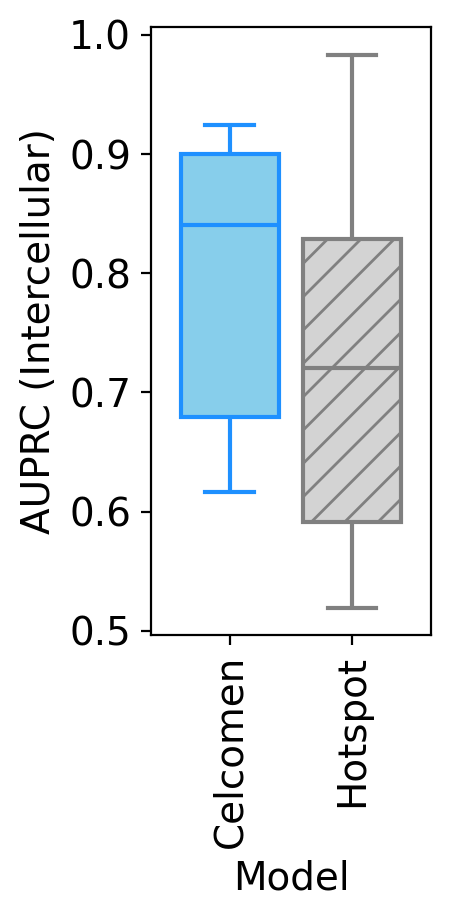

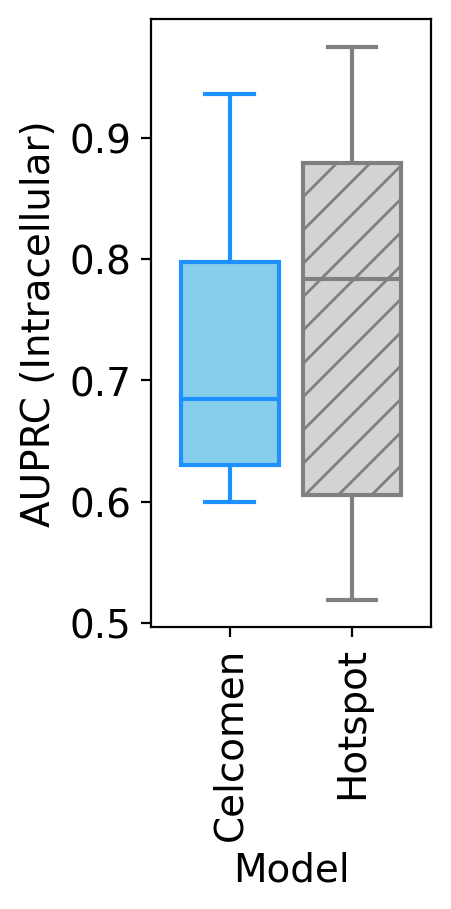

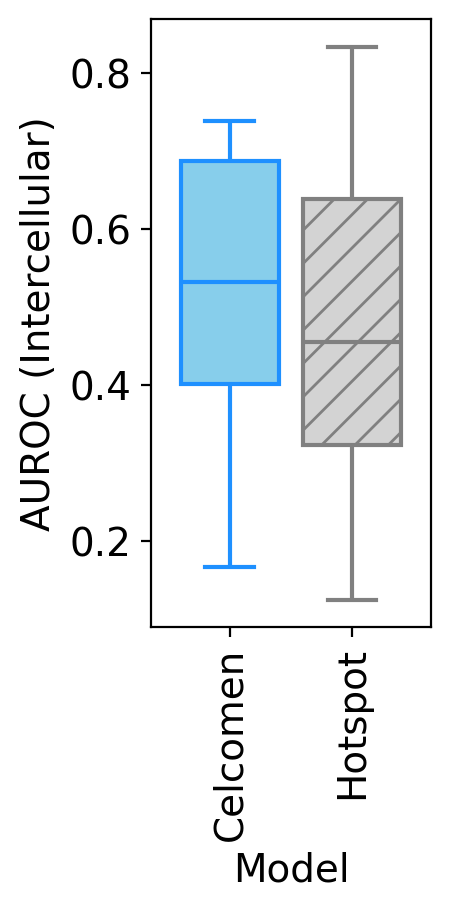

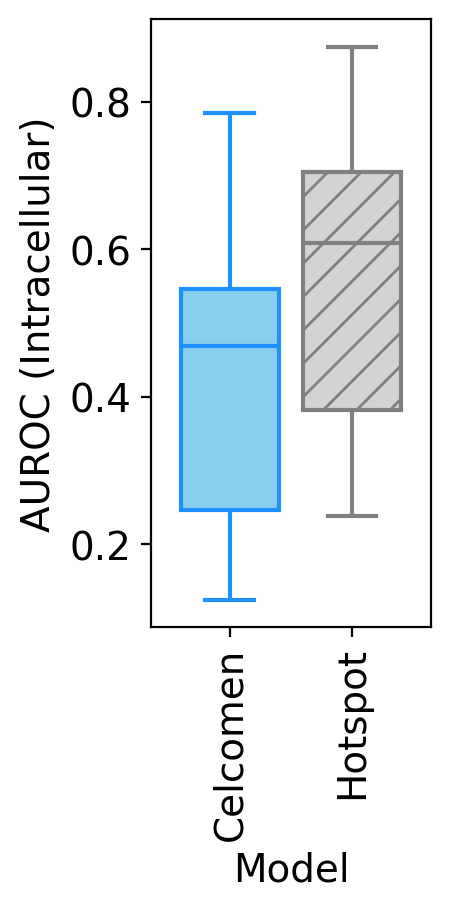

In [3]:
import scipy.stats as ss
import matplotlib as mpl
# take the average of the data
mask = (compiled['gen_func'] == 'gen_dense_any')
mask = mask & (compiled['adj_func'] == 'adj_abs')
# color on the data
prefixs = ['auprc_ex','auprc_in','auroc_ex','auroc_in']
labels = ['AUPRC (Intercellular)','AUPRC (Intracellular)','AUROC (Intercellular)','AUROC (Intracellular)']
for prefix, label in zip(prefixs, labels):
    fig, ax = plt.subplots(figsize=[1.8, 4]); ax.grid(False)
    sns.boxplot(x=0, y=f'{prefix}_celcomen', data=compiled.loc[mask], linecolor='dodgerblue', linewidth=1.5, color='skyblue', saturation=1)
    sns.boxplot(x=1, y=f'{prefix}_hotspot', data=compiled.loc[mask], color='lightgray', linecolor='grey', linewidth=1.5, saturation=1)
    ax.set_xticklabels(['Celcomen','Hotspot'])
    ax.set(xlabel='Model', ylabel=label)
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_xlim(-0.65, 1.65)

    # select the correct patches
    patches = [patch for patch in ax.patches if type(patch) == mpl.patches.PathPatch]
    # iterate through the patches for each subplot
    for patch, hatch in zip(patches[1:2], ['//']):
        patch.set_hatch(hatch)

    print(label, ss.mannwhitneyu(compiled.loc[mask][f'{prefix}_celcomen'], compiled.loc[mask][f'{prefix}_hotspot'])[1])

In [55]:
print()